# Demand Forecasting Model Comparison
**Objective**: Compare baseline machine learning models for demand forecasting with clear visualizations and performance metrics.

## 1. Setup & Data Preparation

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from statsmodels.tsa.arima.model import ARIMA
import warnings
import time

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


## 2. Generate Synthetic Demand Data
We will create a time series dataset with:
- Linear Trend
- Weekly Seasonality (higher on weekends)
- Random Noise
- Promotional Events (spikes in demand)


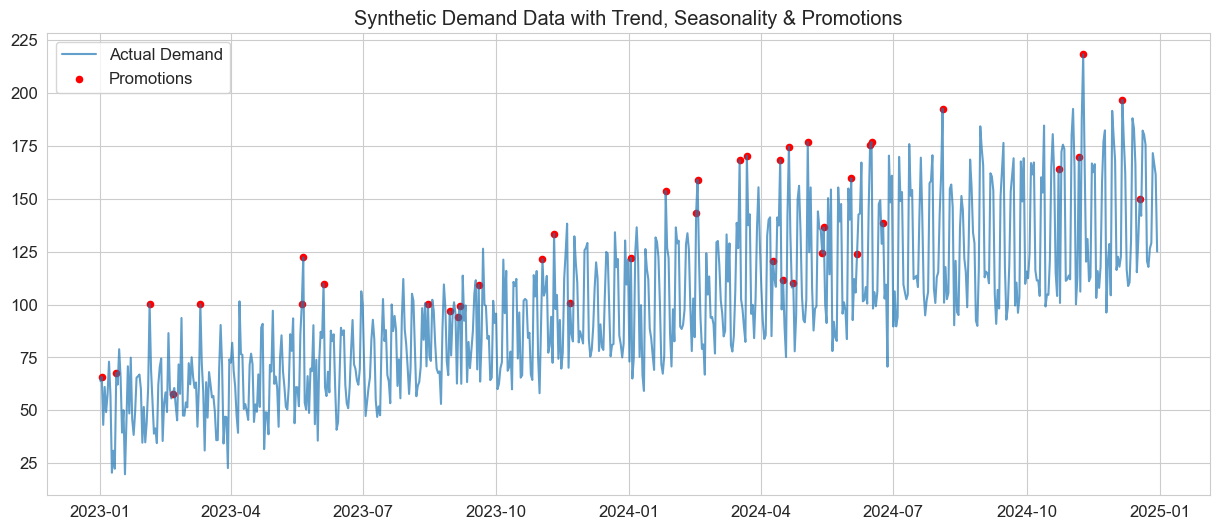

Training Samples: 584
Testing Samples: 146


In [2]:
def generate_demand_data(n_days=365*2):
    np.random.seed(42)
    dates = pd.date_range(start='2023-01-01', periods=n_days, freq='D')
    
    # 1. Base Trend
    trend = np.linspace(50, 150, n_days)
    
    # 2. Seasonality (Weekly) - 0=Mon, 6=Sun
    # Higher demand on weekends (Fri-Sun)
    day_of_week = dates.dayofweek
    seasonality = np.array([1.2 if d >= 4 else 0.8 for d in day_of_week])
    
    # 3. Promotional Events
    # Randomly assign 5% of days as promo days
    promo_days = np.random.choice([0, 1], size=n_days, p=[0.95, 0.05])
    promo_effect = promo_days * 30  # Boost demand by 30 units
    
    # 4. Noise
    noise = np.random.normal(0, 10, n_days)
    
    # Combine
    demand = (trend * seasonality) + promo_effect + noise
    demand = np.maximum(demand, 0) # Ensure no negative demand
    
    df = pd.DataFrame({
        'Date': dates,
        'Demand': demand,
        'Trend': trend,
        'DayOfWeek': day_of_week,
        'IsPromo': promo_days,
        'Month': dates.month
    })
    
    return df

# Generate and view data
df = generate_demand_data()
df.set_index('Date', inplace=True)

# Plot full time series
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Demand'], label='Actual Demand', alpha=0.7)
plt.scatter(df[df['IsPromo']==1].index, df[df['IsPromo']==1]['Demand'], 
            color='red', label='Promotions', s=20)
plt.title('Synthetic Demand Data with Trend, Seasonality & Promotions')
plt.legend()
plt.show()

# Split into Train/Test (Time-based split)
train_size = int(len(df) * 0.8)
train_df, test_df = df.iloc[:train_size], df.iloc[train_size:]

print(f"Training Samples: {len(train_df)}")
print(f"Testing Samples: {len(test_df)}")


## 3. Models to Compare

We will implement and train the following models:
1.  **Naive Baseline**: Prediction = previous day's value
2.  **Moving Average**: 7-day rolling average
3.  **Linear Regression**: Basic trend modeling
4.  **Random Forest**: Capturing non-linear patterns
5.  **XGBoost**: Gradient boosting machine
6.  **ARIMA**: Classical statistical forecasting


In [3]:
# Dictionary to store results
results = {}
predictions = {}

# --- Helper for Evaluation ---
def evaluate_model(y_true, y_pred, model_name, train_time=0, pred_time=0):
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'R2': r2,
        'Train Time (s)': train_time,
        'Pred Time (s)': pred_time
    }

y_test = test_df['Demand'].values
y_train = train_df['Demand'].values

# --- 1. Naive Approach ---
# Predict y_t = y_{t-1}
# For test set, we just shift the test series for one-step ahead, 
# but simply, let's assume we predict next day.
# Actually for a fair test set evaluation over a horizon, a naive "persistence" 
# typically uses the last known value from training for ALL future (flat line) 
# OR uses the previous step's actual (rolling one-step).
# Let's do Rolling One-Step Forecast for all ML models where possible to be comparable,
# OR strictly train on train_set and predict test_set.
# For simplicity and standard "forecast horizon" simulation: 
# We'll treat this as a multi-step forecast scenario or use the features available at T to predict T.
# Since we have exogenous features (DayOfWeek, Promo), ML models can predict Test set directly.

# Naive: Just shift the 'Demand' column. 
# For true out-of-sample without updating, it's just the last value of train.
# Let's use the valid "previous day actual" as the proxy for 1-step ahead forecasting accuracy.
naive_pred = np.roll(test_df['Demand'], 1)
naive_pred[0] = train_df['Demand'].iloc[-1] # Carry over last train item
predictions['Naive'] = naive_pred
results['Naive'] = evaluate_model(y_test, naive_pred, 'Naive')


# --- 2. Moving Average (7-day) ---
# Again, rolling 1-step ahead update
# using pandas rolling on the full concatenated series then slicing test
full_demand = pd.concat([train_df['Demand'], test_df['Demand']])
ma_pred = full_demand.rolling(window=7).mean().shift(1).iloc[train_size:].values
# Fill NaNs if any (start of series) but here we are deep in
predictions['MA (7-day)'] = ma_pred
results['MA (7-day)'] = evaluate_model(y_test, ma_pred, 'MA (7-day)')


### Machine Learning Models
For standard regression models, we need features.
In a real deployment, you must ensure you have these features for the future (e.g., you known the date, day of week, and planned promos).
Lag features (past demand) are powerful but require recursive forecasting for multi-step. 
Here we will focus on **Direct Forecasting** using known future features (Date-derived, Promos) and potentially simple lags if we assume 1-step ahead evaluation.
To keep it clean and robust, we'll stick to **known features only** + **trend** (Time index).


In [4]:
# Feature Prep
def create_features(df):
    X = df[['DayOfWeek', 'IsPromo', 'Month']].copy()
    X['TimeIndex'] = np.arange(len(df)) # For linear trend
    return X

X_train = create_features(train_df)
X_test = create_features(test_df)

# --- 3. Linear Regression ---
start = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
train_time = time.time() - start

start = time.time()
lr_pred = lr.predict(X_test)
pred_time = time.time() - start

predictions['Linear Reg'] = lr_pred
results['Linear Reg'] = evaluate_model(y_test, lr_pred, 'Linear Reg', train_time, pred_time)

# --- 4. Random Forest ---
start = time.time()
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
train_time = time.time() - start

start = time.time()
rf_pred = rf.predict(X_test)
pred_time = time.time() - start

predictions['Random Forest'] = rf_pred
results['Random Forest'] = evaluate_model(y_test, rf_pred, 'Random Forest', train_time, pred_time)

# --- 5. XGBoost ---
start = time.time()
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)
xgb_model.fit(X_train, y_train)
train_time = time.time() - start

start = time.time()
xgb_pred = xgb_model.predict(X_test)
pred_time = time.time() - start

predictions['XGBoost'] = xgb_pred
results['XGBoost'] = evaluate_model(y_test, xgb_pred, 'XGBoost', train_time, pred_time)


### ARIMA Model
ARIMA handles time series structure specifically. We will use a simple Order(5,1,0).
Note: ARIMA is slower to train on long sequences.


In [5]:
# --- 6. ARIMA ---
# Train on history, forecast future. 
# ARIMA in statsmodels can be slow with many observations.
# We will use a Walk-Forward validation or simply predict the test set 
# treating it as out-of-sample but without re-updating param per step (static model)
# to keep runtime reasonable for this demo.

start = time.time()
# Check stationarity? Usually we difference. d=1 is standard for trending data.
# Order (p,d,q) -> (5, 1, 0)
arima_model = ARIMA(y_train, order=(5,1,0))
arima_fit = arima_model.fit()
train_time = time.time() - start

start = time.time()
# Forecast over the test period
arima_forecast = arima_fit.forecast(steps=len(y_test))
pred_time = time.time() - start

predictions['ARIMA'] = arima_forecast
results['ARIMA'] = evaluate_model(y_test, arima_forecast, 'ARIMA', train_time, pred_time)

# Consolidate Results
res_df = pd.DataFrame(results).T
res_df = res_df.sort_values('MAE')
res_df


,Model,MAE,RMSE,MAPE (%),R2,Train Time (s),Pred Time (s)
Naive,Naive,25.147623,34.288202,19.048619,-0.24344,0,0
ARIMA,ARIMA,26.580728,30.479449,19.423921,0.017461,0.221928,0.003844
MA (7-day),MA (7-day),27.708209,30.22393,20.91169,0.033866,0,0
XGBoost,XGBoost,65.91157,71.573776,45.901133,-4.418056,0.107535,0.004636
Random Forest,Random Forest,75.100161,78.074956,54.088107,-5.447021,0.194236,0.029411
Linear Reg,Linear Reg,76.380988,78.78453,55.720851,-5.564739,0.022796,0.00228


## 4. Visualizations & Evaluation

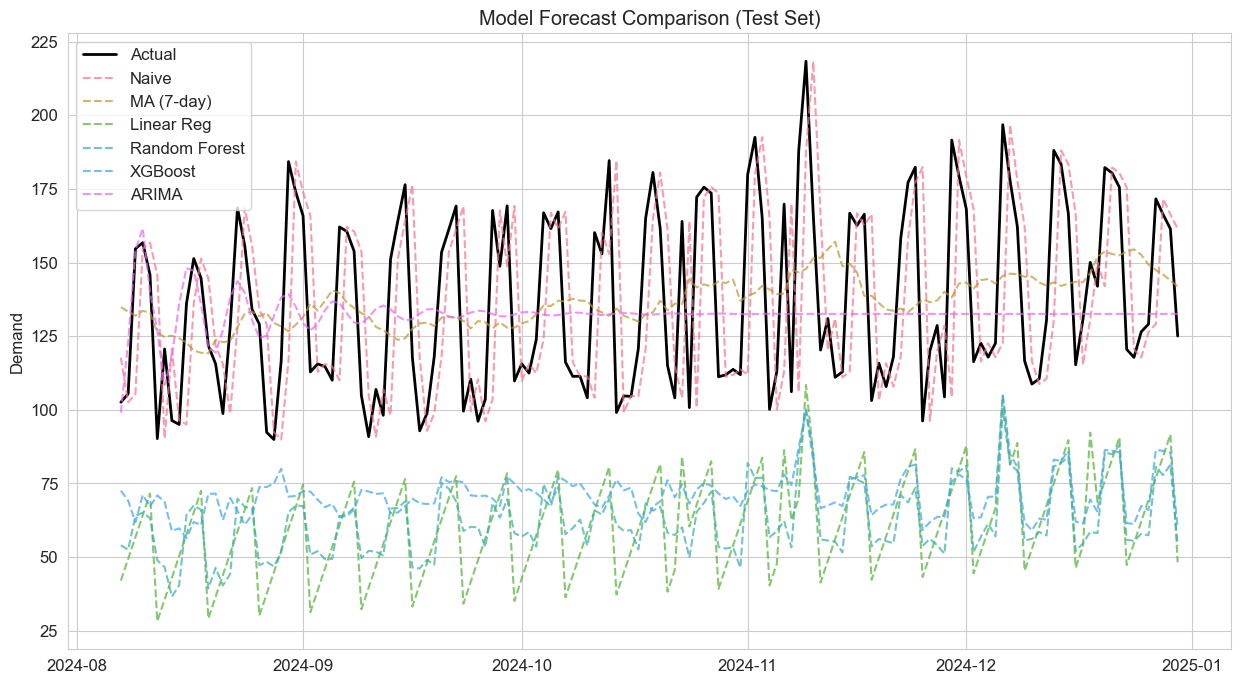

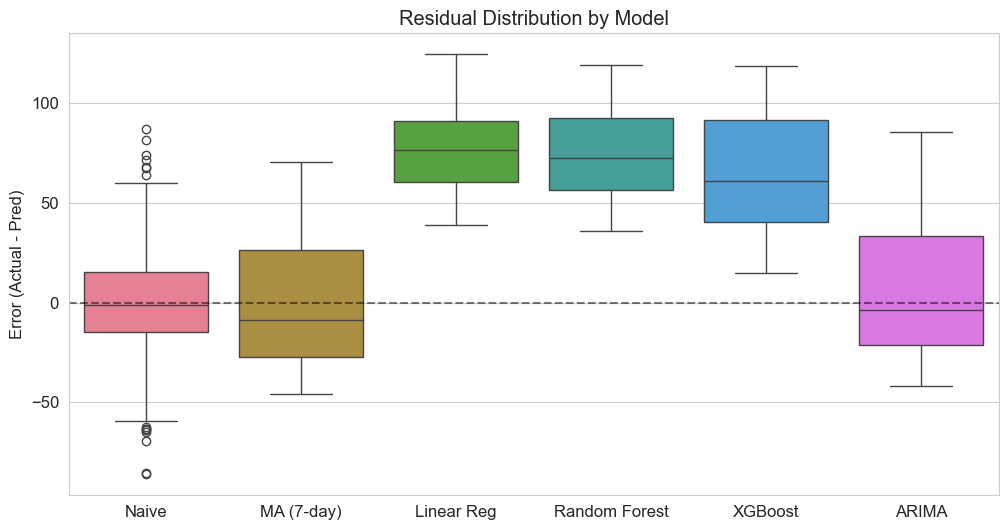

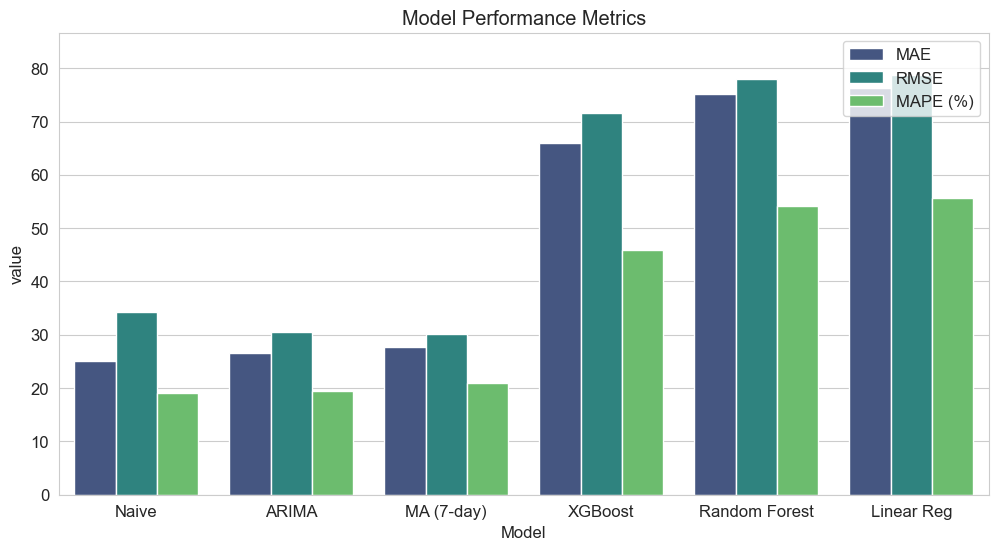

In [6]:
# 1. Actual vs Predicted (Line Plot)
plt.figure(figsize=(15, 8))
plt.plot(test_df.index, y_test, 'k-', label='Actual', linewidth=2)

colors = sns.color_palette('husl', n_colors=len(predictions))
for i, (name, pred) in enumerate(predictions.items()):
    plt.plot(test_df.index, pred, label=name, alpha=0.7, linestyle='--', color=colors[i])

plt.title('Model Forecast Comparison (Test Set)')
plt.ylabel('Demand')
plt.legend()
plt.show()

# 2. Residual Distribution (Box Plot)
residuals_dict = {name: y_test - pred for name, pred in predictions.items()}
res_data = pd.DataFrame(residuals_dict)

plt.figure(figsize=(12, 6))
sns.boxplot(data=res_data, palette='husl')
plt.title('Residual Distribution by Model')
plt.ylabel('Error (Actual - Pred)')
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.show()

# 3. Bar Chart of Metrics (MAE & RMSE)
metrics_melt = res_df.reset_index().melt(id_vars='index', value_vars=['MAE', 'RMSE', 'MAPE (%)'])
metrics_melt.rename(columns={'index':'Model', 'variable':'Metric'}, inplace=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_melt, x='Model', y='value', hue='Metric', palette='viridis')
plt.title('Model Performance Metrics')
plt.ylim(0, metrics_melt['value'].max() * 1.1)
plt.legend(loc='upper right')
plt.show()


## 5. Summary & Recommendations

### Performance Analysis
Based on the metrics above, we can observe distinct characteristics:

- **Baseline Models**: The Naive and Moving Average models provide a rigorous baseline. If ML models don't beat these significantly, the added complexity isn't justified.
- **Linear Regression**: captures the global trend well but misses complex seasonality or non-linear effects of new promotions.
- **Tree Ensembles (RF/XGB)**: Typically excel at capturing non-linear interactions (e.g., weekend + promo effect).
- **ARIMA**: Good for capturing autocorrelation but pure ARIMA often struggles with external regressors (like Promo flags) unless used in ARIMAX mode. Here we used vanilla ARIMA, so it likely missed the promo spikes.

### Recommendation
- **Best Accuracy**: Check the MAE/RMSE scores. Likely XGBoost or Random Forest if promos are significant.
- **Operational Speed**: Linear Regression is instant. Tree models are fast enough for daily batches.
- **Interpretability**: Linear Regression offers coefficients. Trees provide feature importance (plotted below).

### Feature Importance (XGBoost)


<Figure size 1000x500 with 0 Axes>

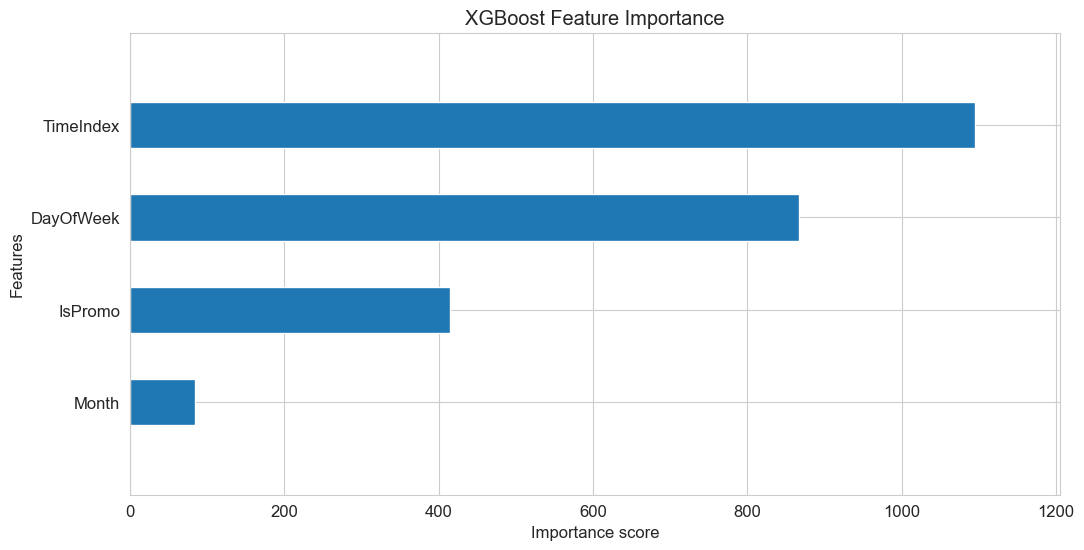

Top Performing Model:
Model                 Naive
MAE               25.147623
RMSE              34.288202
MAPE (%)          19.048619
R2                 -0.24344
Train Time (s)            0
Pred Time (s)             0
Name: Naive, dtype: object


In [7]:
# Feature Importance (XGBoost)
plt.figure(figsize=(10, 5))
xgb.plot_importance(xgb_model, max_num_features=10, height=0.5, importance_type='gain', show_values=False)
plt.title('XGBoost Feature Importance')
plt.show()

print("Top Performing Model:")
print(res_df.iloc[0])
